# CIDA-RIDS: Complete Pipeline
### Curriculum Importance-Weighted Diverse-Attack Robust Intrusion Detection System
**Iowa State University — CPRE 560**  
Run on Google Colab with GPU enabled (Runtime → Change runtime type → T4 GPU)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
%cd /content/drive/MyDrive/CPR560/Team_Project/final_project

/content/drive/MyDrive/CPR560/Team_Project/final_project


In [4]:
import os, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split, Subset
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 130

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print("Running on Google Colab - GPU is enabled" if torch.cuda.is_available() else "Warning: GPU not found")

os.makedirs("checkpoints", exist_ok=True)


Device: cuda
Running on Google Colab - GPU is enabled


## 1. Model Definitions

In [5]:
class ClassifierMLP(nn.Module):
    """3-layer MLP: input -> 128 -> 64 -> 32 -> num_classes (BatchNorm + Dropout)."""
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),         nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        return self.net(x)


class DenoisingAutoencoder(nn.Module):
    """C5 denoising AE: input -> 64 -> 32 -> 64 -> input."""
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32),        nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),        nn.ReLU(),
            nn.Linear(64, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))


## 2. Data Loading & Preprocessing (NSL-KDD)

In [6]:
print("=" * 60)
print("CIDA-RIDS: Complete Pipeline")
print("=" * 60)

train_url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt"
test_url  = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"

columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','attack_type','difficulty_level'
]

df_train = pd.read_csv(train_url, header=None, names=columns)
df_test  = pd.read_csv(test_url,  header=None, names=columns)
print(f"Train: {df_train.shape}  |  Test: {df_test.shape}")

# Binary labels: normal=0, attack=1
df_train['label'] = (df_train['attack_type'] != 'normal').astype(int)
df_test['label']  = (df_test['attack_type']  != 'normal').astype(int)

X_train_raw = df_train.drop(['attack_type','difficulty_level','label'], axis=1)
y_train     = df_train['label'].values
X_test_raw  = df_test.drop(['attack_type','difficulty_level','label'], axis=1)
y_test      = df_test['label'].values

# One-hot encode categorical columns
cat_cols = ['protocol_type','service','flag']
X_train_enc = pd.get_dummies(X_train_raw, columns=cat_cols)
X_test_enc  = pd.get_dummies(X_test_raw,  columns=cat_cols)
X_test_enc  = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

for df in [X_train_enc, X_test_enc]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)

scaler      = MinMaxScaler()
X_train_sc  = scaler.fit_transform(X_train_enc)
X_test_sc   = scaler.transform(X_test_enc)
print(f"After encoding — Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}")

# Quick RF baseline
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train_sc, y_train)
print(f"Random Forest baseline accuracy: {rf.score(X_test_sc, y_test):.4f}")


CIDA-RIDS: Complete Pipeline
Train: (125973, 43)  |  Test: (22544, 43)
After encoding — Train: (125973, 122)  |  Test: (22544, 122)
Random Forest baseline accuracy: 0.7559


## 3. Feature Selection (C1) & Mutability Mask (C2)

In [7]:
def select_features_and_importance(X_train, y_train, percentile=0.6):
    """C1: ExtraTrees feature selection, returns selected indices + importance vector."""
    clf = ExtraTreesClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)
    imp = clf.feature_importances_
    threshold   = np.percentile(imp, (1 - percentile) * 100)
    sel_idx     = np.where(imp >= threshold)[0]
    imp_vec     = np.zeros_like(imp)
    imp_vec[sel_idx] = imp[sel_idx]
    if imp_vec.sum() > 0:
        imp_vec /= imp_vec.sum()
    return sel_idx, imp_vec


def get_mutability_mask(num_features, immutable_indices=None):
    """C2: Binary mask — 1 = mutable, 0 = immutable (protocol semantics)."""
    if immutable_indices is None:
        immutable_indices = [0, 1, 2]
    mask = np.ones(num_features, dtype=np.float32)
    mask[immutable_indices] = 0.0
    return mask


print("[C1] Feature selection...")
selected_idx, importance_vector = select_features_and_importance(X_train_sc, y_train)
X_train_sel = X_train_sc[:, selected_idx]
X_test_sel  = X_test_sc[:,  selected_idx]
imp_vec_sel = importance_vector[selected_idx]
print(f"  Selected {len(selected_idx)} / {X_train_sc.shape[1]} features")

print("[C2] Mutability mask...")
immutable_indices = [0, 1, 2] if len(selected_idx) > 3 else [0, 1]
mutability_mask   = get_mutability_mask(X_train_sel.shape[1], immutable_indices)
n_mutable   = int(mutability_mask.sum())
n_immutable = len(mutability_mask) - n_mutable
print(f"  Mutable: {n_mutable}  |  Immutable: {n_immutable}")


[C1] Feature selection...
  Selected 73 / 122 features
[C2] Mutability mask...
  Mutable: 70  |  Immutable: 3


## 4. DataLoaders

In [8]:
input_dim   = X_train_sel.shape[1]
num_classes = len(np.unique(y_train))

train_ds = TensorDataset(torch.tensor(X_train_sel, dtype=torch.float32),
                         torch.tensor(y_train, dtype=torch.long))
test_ds  = TensorDataset(torch.tensor(X_test_sel,  dtype=torch.float32),
                         torch.tensor(y_test,  dtype=torch.long))

train_size = int(0.9 * len(train_ds))
val_size   = len(train_ds) - train_size
train_sub, val_sub = random_split(train_ds, [train_size, val_size])

BATCH = 128
train_loader = DataLoader(train_sub, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_sub,   batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(test_ds,   batch_size=BATCH, shuffle=False)
fast_loader  = DataLoader(Subset(test_ds, list(range(min(2000, len(test_ds))))),
                          batch_size=256, shuffle=False)

print(f"Input dim: {input_dim}  |  Classes: {num_classes}")
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}  |  Test samples: {len(test_ds)}")


Input dim: 73  |  Classes: 2
Train batches: 886  |  Val batches: 99  |  Test samples: 22544


## 5. Attack Functions (N1: IW-PGD, IW-FGSM + Uniform variants)

In [9]:
def iw_pgd_attack(model, x, y, epsilon_total, importance_vector, mutability_mask,
                  steps=10, alpha=0.01, restarts=1):
    """N1: Importance-Weighted PGD. Per-feature budget proportional to importance."""
    model.eval()
    mutable_idx = np.where(mutability_mask == 1)[0]
    sum_imp     = importance_vector[mutable_idx].sum()
    num_mutable = len(mutable_idx)

    per_eps = np.zeros_like(importance_vector, dtype=np.float32)
    for i in mutable_idx:
        per_eps[i] = (importance_vector[i] / sum_imp * epsilon_total * num_mutable
                      if sum_imp > 0 else epsilon_total)

    eps_t  = torch.tensor(per_eps,       dtype=torch.float32, device=device).unsqueeze(0)
    mask_t = torch.tensor(mutability_mask, dtype=torch.float32, device=device).unsqueeze(0)

    best_adv, best_loss = None, -float('inf')
    for _ in range(restarts):
        delta = torch.zeros_like(x, requires_grad=True)
        with torch.no_grad():
            for i in range(delta.shape[1]):
                delta[:, i] = torch.empty(x.shape[0]).uniform_(
                    -eps_t[0, i].item(), eps_t[0, i].item()).to(device)
        delta = (delta * mask_t).detach().requires_grad_(True)

        for _ in range(steps):
            loss = nn.CrossEntropyLoss()(model(x + delta), y)
            loss.backward()
            with torch.no_grad():
                delta.data += alpha * delta.grad.sign()
                delta.data  = delta.data * mask_t
                for i in range(delta.shape[1]):
                    delta.data[:, i] = delta.data[:, i].clamp(-eps_t[0,i], eps_t[0,i])
            delta.grad.zero_()

        with torch.no_grad():
            fl = nn.CrossEntropyLoss()(model(x + delta), y).item()
        if fl > best_loss:
            best_loss = fl
            best_adv  = (x + delta).detach()

    model.train()
    return best_adv


def iw_fgsm_attack(model, x, y, epsilon_total, importance_vector, mutability_mask):
    """N1: Single-step IW-FGSM."""
    return iw_pgd_attack(model, x, y, epsilon_total, importance_vector,
                         mutability_mask, steps=1, alpha=epsilon_total, restarts=1)


def uniform_pgd_attack(model, x, y, epsilon, mutability_mask, steps=10, alpha=0.01):
    """Standard PGD with uniform budget across mutable features."""
    model.eval()
    mask_t = torch.tensor(mutability_mask, dtype=torch.float32, device=device).unsqueeze(0)
    delta  = ((torch.rand_like(x) * 2 - 1) * epsilon * mask_t).detach().requires_grad_(True)
    for _ in range(steps):
        loss = nn.CrossEntropyLoss()(model(x + delta), y)
        loss.backward()
        with torch.no_grad():
            delta.data = (delta.data + alpha * delta.grad.sign() * mask_t).clamp(-epsilon, epsilon) * mask_t
        delta.grad.zero_()
    model.train()
    return (x + delta).detach()


def uniform_fgsm_attack(model, x, y, epsilon, mutability_mask):
    """Single-step uniform FGSM."""
    model.eval()
    mask_t = torch.tensor(mutability_mask, dtype=torch.float32, device=device).unsqueeze(0)
    x_in   = x.clone().detach().requires_grad_(True)
    nn.CrossEntropyLoss()(model(x_in), y).backward()
    with torch.no_grad():
        adv = x + epsilon * x_in.grad.sign() * mask_t
    model.train()
    return adv.detach()


print("Attack functions defined: iw_pgd_attack, iw_fgsm_attack, uniform_pgd_attack, uniform_fgsm_attack")


Attack functions defined: iw_pgd_attack, iw_fgsm_attack, uniform_pgd_attack, uniform_fgsm_attack


## 6. CIDA-RIDS Trainer (N1 + N2 + N3 + C3 + C4)

In [10]:
class CIDARIDSTrainer:
    """Full CIDA-RIDS training: IW-PGD (N1) + curriculum ε (N2) + multi-attack diversity (N3)
    + label smoothing (C3) + Gaussian augmentation (C4)."""

    def __init__(self, model, train_loader, val_loader, importance_vector, mutability_mask,
                 num_epochs=50, epsilon_max=0.20, epsilon_min=0.01,
                 label_smoothing=0.1, gaussian_std=0.05, lr=0.001):
        self.model           = model
        self.train_loader    = train_loader
        self.val_loader      = val_loader
        self.imp_vec         = importance_vector
        self.mut_mask        = mutability_mask
        self.num_epochs      = num_epochs
        self.epsilon_max     = epsilon_max
        self.epsilon_min     = epsilon_min
        self.gaussian_std    = gaussian_std
        self.optimizer       = optim.Adam(model.parameters(), lr=lr)
        self.criterion       = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        self.train_losses    = []
        self.val_accuracies  = []
        self.current_epsilon = epsilon_min

    def _epsilon(self, epoch):
        return self.epsilon_min + (epoch / max(1, self.num_epochs - 1)) * (self.epsilon_max - self.epsilon_min)

    def _augment(self, x):
        return x + torch.randn_like(x) * self.gaussian_std if np.random.rand() < 0.25 else x

    def _adv(self, x, y, eps):
        choice = np.random.choice(['iw_pgd','iw_fgsm','gaussian'], p=[0.5, 0.25, 0.25])
        if choice == 'iw_pgd':
            return iw_pgd_attack(self.model, x, y, eps, self.imp_vec, self.mut_mask,
                                 steps=10, alpha=eps/4)
        elif choice == 'iw_fgsm':
            return iw_fgsm_attack(self.model, x, y, eps, self.imp_vec, self.mut_mask)
        else:
            return x + torch.randn_like(x) * self.gaussian_std

    def train(self, verbose=True):
        print("\n" + "="*60)
        print("Starting CIDA-RIDS Training")
        print("="*60)
        for epoch in range(self.num_epochs):
            self.model.train()
            eps = self._epsilon(epoch)
            self.current_epsilon = eps
            total_loss = 0
            for bx, by in self.train_loader:
                bx, by = bx.to(device), by.to(device)
                adv_x  = self._adv(self._augment(bx), by, eps)
                loss   = self.criterion(self.model(adv_x), by)
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()
            self.train_losses.append(total_loss / len(self.train_loader))

            if (epoch + 1) % 5 == 0 or epoch == 0:
                val_acc = self._validate()
                self.val_accuracies.append(val_acc)
                if verbose:
                    print(f"Epoch {epoch+1:3d}/{self.num_epochs} | "
                          f"Loss: {self.train_losses[-1]:.4f} | "
                          f"Eps: {eps:.3f} | Val Acc: {val_acc:.4f}")
            elif verbose and (epoch + 1) % 2 == 0:
                print(f"Epoch {epoch+1:3d}/{self.num_epochs} | "
                      f"Loss: {self.train_losses[-1]:.4f} | Eps: {eps:.3f}")

        final_acc = self._validate()
        print("\n" + "="*60)
        print(f"Training complete. Final Val Acc: {final_acc:.4f}")
        print("="*60)
        return self.train_losses, self.val_accuracies

    def _validate(self):
        self.model.eval()
        correct = total = 0
        with torch.no_grad():
            for bx, by in self.val_loader:
                bx, by = bx.to(device), by.to(device)
                correct += (self.model(bx).argmax(1) == by).sum().item()
                total   += by.size(0)
        self.model.train()
        return correct / total


## 7. Denoising Autoencoder Training (C5)

In [11]:
def train_denoising_autoencoder(ae_model, train_loader, epochs=30, lr=0.001, noise_std=0.05):
    print("\n" + "="*60)
    print("Training Denoising Autoencoder (C5)")
    print("="*60)
    optimizer = optim.Adam(ae_model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    ae_model.train()
    for epoch in range(epochs):
        total = 0
        for bx, _ in train_loader:
            bx = bx.to(device)
            recon = ae_model(bx + torch.randn_like(bx) * noise_std)
            loss  = criterion(recon, bx)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total += loss.item()
        if (epoch + 1) % 10 == 0:
            print(f"  AE Epoch {epoch+1:3d}/{epochs} | Loss: {total/len(train_loader):.6f}")
    print("Denoising AE training complete.")
    return ae_model


@torch.no_grad()
def evaluate_with_denoising(model, ae_model, loader):
    model.eval(); ae_model.eval()
    correct = total = 0
    for bx, by in loader:
        bx, by = bx.to(device), by.to(device)
        preds = model(ae_model(bx)).argmax(1)
        correct += (preds == by).sum().item()
        total   += by.size(0)
    return correct / total


# Initialise and train
classifier = ClassifierMLP(input_dim, num_classes).to(device)
denoiser   = DenoisingAutoencoder(input_dim).to(device)
print(f"Classifier parameters: {sum(p.numel() for p in classifier.parameters()):,}")

denoiser = train_denoising_autoencoder(denoiser, train_loader)


Classifier parameters: 20,322

Training Denoising Autoencoder (C5)
  AE Epoch  10/30 | Loss: 0.001032
  AE Epoch  20/30 | Loss: 0.000742
  AE Epoch  30/30 | Loss: 0.000577
Denoising AE training complete.


## 8. Train CIDA-RIDS Classifier

In [12]:
trainer = CIDARIDSTrainer(
    model=classifier, train_loader=train_loader, val_loader=val_loader,
    importance_vector=imp_vec_sel, mutability_mask=mutability_mask,
    num_epochs=50, epsilon_max=0.20, epsilon_min=0.01,
    label_smoothing=0.1, gaussian_std=0.05, lr=0.001
)
train_losses, val_accs = trainer.train(verbose=True)

# ── Save CIDA-RIDS checkpoint (D2) ────────────────────────────────────────────
torch.save(classifier.state_dict(), "checkpoints/cida_rids.pt")
torch.save(denoiser.state_dict(),   "checkpoints/denoiser.pt")
print("\nCheckpoints saved: checkpoints/cida_rids.pt, checkpoints/denoiser.pt")



Starting CIDA-RIDS Training
Epoch   1/50 | Loss: 0.2605 | Eps: 0.010 | Val Acc: 0.9845
Epoch   2/50 | Loss: 0.2418 | Eps: 0.014
Epoch   4/50 | Loss: 0.2404 | Eps: 0.022
Epoch   5/50 | Loss: 0.2402 | Eps: 0.026 | Val Acc: 0.9860
Epoch   6/50 | Loss: 0.2405 | Eps: 0.029
Epoch   8/50 | Loss: 0.2411 | Eps: 0.037
Epoch  10/50 | Loss: 0.2421 | Eps: 0.045 | Val Acc: 0.9854
Epoch  12/50 | Loss: 0.2443 | Eps: 0.053
Epoch  14/50 | Loss: 0.2450 | Eps: 0.060
Epoch  15/50 | Loss: 0.2467 | Eps: 0.064 | Val Acc: 0.9851
Epoch  16/50 | Loss: 0.2472 | Eps: 0.068
Epoch  18/50 | Loss: 0.2488 | Eps: 0.076
Epoch  20/50 | Loss: 0.2513 | Eps: 0.084 | Val Acc: 0.9808
Epoch  22/50 | Loss: 0.2525 | Eps: 0.091
Epoch  24/50 | Loss: 0.2541 | Eps: 0.099
Epoch  25/50 | Loss: 0.2563 | Eps: 0.103 | Val Acc: 0.9802
Epoch  26/50 | Loss: 0.2570 | Eps: 0.107
Epoch  28/50 | Loss: 0.2606 | Eps: 0.115
Epoch  30/50 | Loss: 0.2612 | Eps: 0.122 | Val Acc: 0.9800
Epoch  32/50 | Loss: 0.2628 | Eps: 0.130
Epoch  34/50 | Loss: 0.26

## 9. Evaluation Helpers

In [13]:
def evaluate_attack(model, loader, attack_fn, **kwargs):
    """Returns (acc_under_attack, asr)."""
    model.eval()
    correct = total = 0
    for bx, by in loader:
        bx, by = bx.to(device), by.to(device)
        adv    = attack_fn(model, bx, by, **kwargs)
        preds  = model(adv).argmax(1)
        correct += (preds == by).sum().item()
        total   += by.size(0)
    acc = correct / total
    return acc, 1 - acc


def clean_acc(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for bx, by in loader:
            bx, by = bx.to(device), by.to(device)
            correct += (model(bx).argmax(1) == by).sum().item()
            total   += by.size(0)
    return correct / total


def gradient_attribution(model, x):
    """Gradient × input attribution (SHAP proxy)."""
    model.eval()
    x_in = x.clone().detach().requires_grad_(True)
    logits = model(x_in)
    logits[range(len(logits)), logits.argmax(1)].sum().backward()
    return (x_in.grad * x_in).abs().detach().cpu().numpy()


def explanation_stability(model, loader, eps=0.10, n_batches=5):
    """Spearman ρ between clean and adversarial gradient attributions."""
    rhos = []
    for i, (bx, by) in enumerate(loader):
        if i >= n_batches: break
        bx, by = bx.to(device), by.to(device)
        attr_clean = gradient_attribution(model, bx).mean(0)
        adv_x      = iw_pgd_attack(model, bx, by, epsilon_total=eps,
                                    importance_vector=imp_vec_sel,
                                    mutability_mask=mutability_mask,
                                    steps=10, alpha=eps/4)
        attr_adv   = gradient_attribution(model, adv_x).mean(0)
        rhos.append(spearmanr(attr_clean, attr_adv).statistic)
    return float(np.mean(rhos))


print("Evaluation helpers defined.")


Evaluation helpers defined.


## 10. Initial CIDA-RIDS Evaluation

In [14]:
print("\n[CIDA-RIDS] Final evaluation on test set...")

clean_cida = evaluate_with_denoising(classifier, denoiser, test_loader)
print(f"  Clean test accuracy (with denoising): {clean_cida:.4f}")

acc_iwpgd, asr_iwpgd = evaluate_attack(
    classifier, fast_loader, iw_pgd_attack,
    epsilon_total=0.15, importance_vector=imp_vec_sel,
    mutability_mask=mutability_mask, steps=10, alpha=0.01
)
print(f"  Accuracy under IW-PGD (ε=0.15): {acc_iwpgd:.4f}")
print(f"  Attack Success Rate:             {asr_iwpgd:.4f}")
print(f"  Robustness Gap:                  {clean_cida - acc_iwpgd:.4f}")



[CIDA-RIDS] Final evaluation on test set...
  Clean test accuracy (with denoising): 0.7758
  Accuracy under IW-PGD (ε=0.15): 0.7695
  Attack Success Rate:             0.2305
  Robustness Gap:                  0.0063


## 11. Ablation Study — Baselines B1 & B3

- **B1**: Clean DNN (no adversarial training, no denoiser)
- **B3**: Uniform PGD-AT (equal ε across all mutable features)
- **CIDA-RIDS**: already trained above


In [15]:
def train_baseline(name, epochs=50, use_adv=False, adv_fn=None,
                   adv_kwargs=None, label_smoothing=0.0):
    """Generic baseline trainer — returns trained model."""
    print(f"\n{'='*55}\nTraining: {name}\n{'='*55}")
    model     = ClassifierMLP(input_dim, num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    for epoch in range(epochs):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            if use_adv and adv_fn is not None:
                bx = adv_fn(model, bx, by, **adv_kwargs)
            optimizer.zero_grad()
            criterion(model(bx), by).backward()
            optimizer.step()

        if (epoch + 1) % 10 == 0 or epoch == 0:
            acc = clean_acc(model, val_loader)
            print(f"  Epoch {epoch+1:3d}/{epochs} | Val Acc: {acc:.4f}")

    return model


# ── B1: Clean DNN ─────────────────────────────────────────────────────────────
model_b1 = train_baseline("B1 — Clean DNN", epochs=50)
torch.save(model_b1.state_dict(), "checkpoints/b1_clean_dnn.pt")
print("Saved: checkpoints/b1_clean_dnn.pt")

# ── B3: Uniform PGD-AT ────────────────────────────────────────────────────────
model_b3 = train_baseline(
    "B3 — Uniform PGD-AT", epochs=50,
    use_adv=True, adv_fn=uniform_pgd_attack,
    adv_kwargs=dict(epsilon=0.10, mutability_mask=mutability_mask, steps=10, alpha=0.01),
    label_smoothing=0.1
)
torch.save(model_b3.state_dict(), "checkpoints/b3_uniform_pgd.pt")
print("Saved: checkpoints/b3_uniform_pgd.pt")

print("\nAll checkpoints saved to ./checkpoints/")



Training: B1 — Clean DNN
  Epoch   1/50 | Val Acc: 0.9886
  Epoch  10/50 | Val Acc: 0.9943
  Epoch  20/50 | Val Acc: 0.9956
  Epoch  30/50 | Val Acc: 0.9967
  Epoch  40/50 | Val Acc: 0.9967
  Epoch  50/50 | Val Acc: 0.9965
Saved: checkpoints/b1_clean_dnn.pt

Training: B3 — Uniform PGD-AT
  Epoch   1/50 | Val Acc: 0.9775
  Epoch  10/50 | Val Acc: 0.9803
  Epoch  20/50 | Val Acc: 0.9819
  Epoch  30/50 | Val Acc: 0.9821
  Epoch  40/50 | Val Acc: 0.9817
  Epoch  50/50 | Val Acc: 0.9816
Saved: checkpoints/b3_uniform_pgd.pt

All checkpoints saved to ./checkpoints/


## 12. Clean Accuracy Comparison

In [16]:
clean_b1   = clean_acc(model_b1, test_loader)
clean_b3   = clean_acc(model_b3, test_loader)

print(f"{'Model':<25} {'Clean Test Acc':>15}")
print("-" * 42)
print(f"{'B1 — Clean DNN':<25} {clean_b1:>15.4f}")
print(f"{'B3 — Uniform PGD-AT':<25} {clean_b3:>15.4f}")
print(f"{'CIDA-RIDS (+ denoiser)':<25} {clean_cida:>15.4f}")


Model                      Clean Test Acc
------------------------------------------
B1 — Clean DNN                     0.7985
B3 — Uniform PGD-AT                0.7531
CIDA-RIDS (+ denoiser)             0.7758


## 13. Robustness Sweep — Multi-Attack × Multi-Epsilon

Evaluates all 3 models across 4 attack types × 4 ε values (48 data points total).  
Uses 2,000 test samples for speed — increase `fast_loader` size for final results.


In [17]:
EPSILONS = [0.05, 0.10, 0.15, 0.20]

models_to_eval = [
    ("B1 Clean DNN",      model_b1,   clean_b1),
    ("B3 Uniform PGD-AT", model_b3,   clean_b3),
    ("CIDA-RIDS",         classifier, clean_cida),
]

rows = []

for model_name, model, clean in models_to_eval:
    print(f"\nSweeping {model_name}...")
    for eps in EPSILONS:

        # Uniform FGSM
        a, s = evaluate_attack(model, fast_loader, uniform_fgsm_attack,
                               epsilon=eps, mutability_mask=mutability_mask)
        rows.append(dict(model=model_name, attack="Uniform FGSM",
                         epsilon=eps, clean_acc=clean, acc_under_attack=a,
                         asr=s, robustness_gap=clean-a))

        # Uniform PGD
        a, s = evaluate_attack(model, fast_loader, uniform_pgd_attack,
                               epsilon=eps, mutability_mask=mutability_mask,
                               steps=10, alpha=eps/4)
        rows.append(dict(model=model_name, attack="Uniform PGD",
                         epsilon=eps, clean_acc=clean, acc_under_attack=a,
                         asr=s, robustness_gap=clean-a))

        # IW-FGSM
        a, s = evaluate_attack(model, fast_loader, iw_fgsm_attack,
                               epsilon_total=eps, importance_vector=imp_vec_sel,
                               mutability_mask=mutability_mask)
        rows.append(dict(model=model_name, attack="IW-FGSM",
                         epsilon=eps, clean_acc=clean, acc_under_attack=a,
                         asr=s, robustness_gap=clean-a))

        # IW-PGD
        a, s = evaluate_attack(model, fast_loader, iw_pgd_attack,
                               epsilon_total=eps, importance_vector=imp_vec_sel,
                               mutability_mask=mutability_mask,
                               steps=10, alpha=eps/4)
        rows.append(dict(model=model_name, attack="IW-PGD",
                         epsilon=eps, clean_acc=clean, acc_under_attack=a,
                         asr=s, robustness_gap=clean-a))

        print(f"  ε={eps:.2f} done")

results_df = pd.DataFrame(rows)

# Save CSV (D3)
results_df.to_csv("cida_rids_robustness_results.csv", index=False)
print("\nSaved: cida_rids_robustness_results.csv")



Sweeping B1 Clean DNN...
  ε=0.05 done
  ε=0.10 done
  ε=0.15 done
  ε=0.20 done

Sweeping B3 Uniform PGD-AT...
  ε=0.05 done
  ε=0.10 done
  ε=0.15 done
  ε=0.20 done

Sweeping CIDA-RIDS...
  ε=0.05 done
  ε=0.10 done
  ε=0.15 done
  ε=0.20 done

Saved: cida_rids_robustness_results.csv


## 14. Summary Tables (D3)

In [18]:
print("=== Accuracy Under Attack ===")
pivot_acc = results_df.pivot_table(
    index=["model","attack"], columns="epsilon", values="acc_under_attack").round(4)
print(pivot_acc.to_string())

print("\n=== Attack Success Rate ===")
pivot_asr = results_df.pivot_table(
    index=["model","attack"], columns="epsilon", values="asr").round(4)
print(pivot_asr.to_string())

print("\n=== Robustness Gap (clean − under attack) ===")
pivot_gap = results_df.pivot_table(
    index=["model","attack"], columns="epsilon", values="robustness_gap").round(4)
print(pivot_gap.to_string())


=== Accuracy Under Attack ===
epsilon                           0.05    0.10    0.15    0.20
model             attack                                      
B1 Clean DNN      IW-FGSM       0.5620  0.3250  0.2765  0.2550
                  IW-PGD        0.3475  0.2170  0.1070  0.0400
                  Uniform FGSM  0.2865  0.2380  0.2370  0.2540
                  Uniform PGD   0.2775  0.0990  0.0150  0.0040
B3 Uniform PGD-AT IW-FGSM       0.7740  0.7390  0.6935  0.5990
                  IW-PGD        0.7535  0.6815  0.5495  0.4155
                  Uniform FGSM  0.7730  0.7525  0.7215  0.6975
                  Uniform PGD   0.7695  0.7360  0.6805  0.6235
CIDA-RIDS         IW-FGSM       0.7780  0.7675  0.7655  0.7545
                  IW-PGD        0.7785  0.7635  0.7325  0.6660
                  Uniform FGSM  0.7645  0.7350  0.6965  0.6505
                  Uniform PGD   0.7680  0.7075  0.6000  0.4685

=== Attack Success Rate ===
epsilon                           0.05    0.10    0.15    0

## 15. Explanation Stability — Gradient Attribution (SHAP proxy)

In [19]:
print("Computing explanation stability (Spearman ρ, ε=0.10, 5 batches)...\n")

rho_b1   = explanation_stability(model_b1,   fast_loader, eps=0.10)
rho_b3   = explanation_stability(model_b3,   fast_loader, eps=0.10)
rho_cida = explanation_stability(classifier, fast_loader, eps=0.10)

stability_df = pd.DataFrame([
    {"model": "B1 Clean DNN",      "spearman_rho": rho_b1},
    {"model": "B3 Uniform PGD-AT", "spearman_rho": rho_b3},
    {"model": "CIDA-RIDS",         "spearman_rho": rho_cida},
])

print(f"\n{'Model':<25} {'Spearman ρ':>12}")
print("-" * 38)
for _, r in stability_df.iterrows():
    print(f"{r['model']:<25} {r['spearman_rho']:>12.4f}")
print("\n(Higher ρ = more stable feature rankings under attack)")

stability_df.to_csv("cida_rids_stability.csv", index=False)
print("Saved: cida_rids_stability.csv")


Computing explanation stability (Spearman ρ, ε=0.10, 5 batches)...


Model                       Spearman ρ
--------------------------------------
B1 Clean DNN                    0.8960
B3 Uniform PGD-AT               0.8988
CIDA-RIDS                       0.9288

(Higher ρ = more stable feature rankings under attack)
Saved: cida_rids_stability.csv


## 16. Plots (D3)

/tmp/ipykernel_3513/1897754952.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels([m.replace(" ", "\n") for m in mnames], fontsize=9)


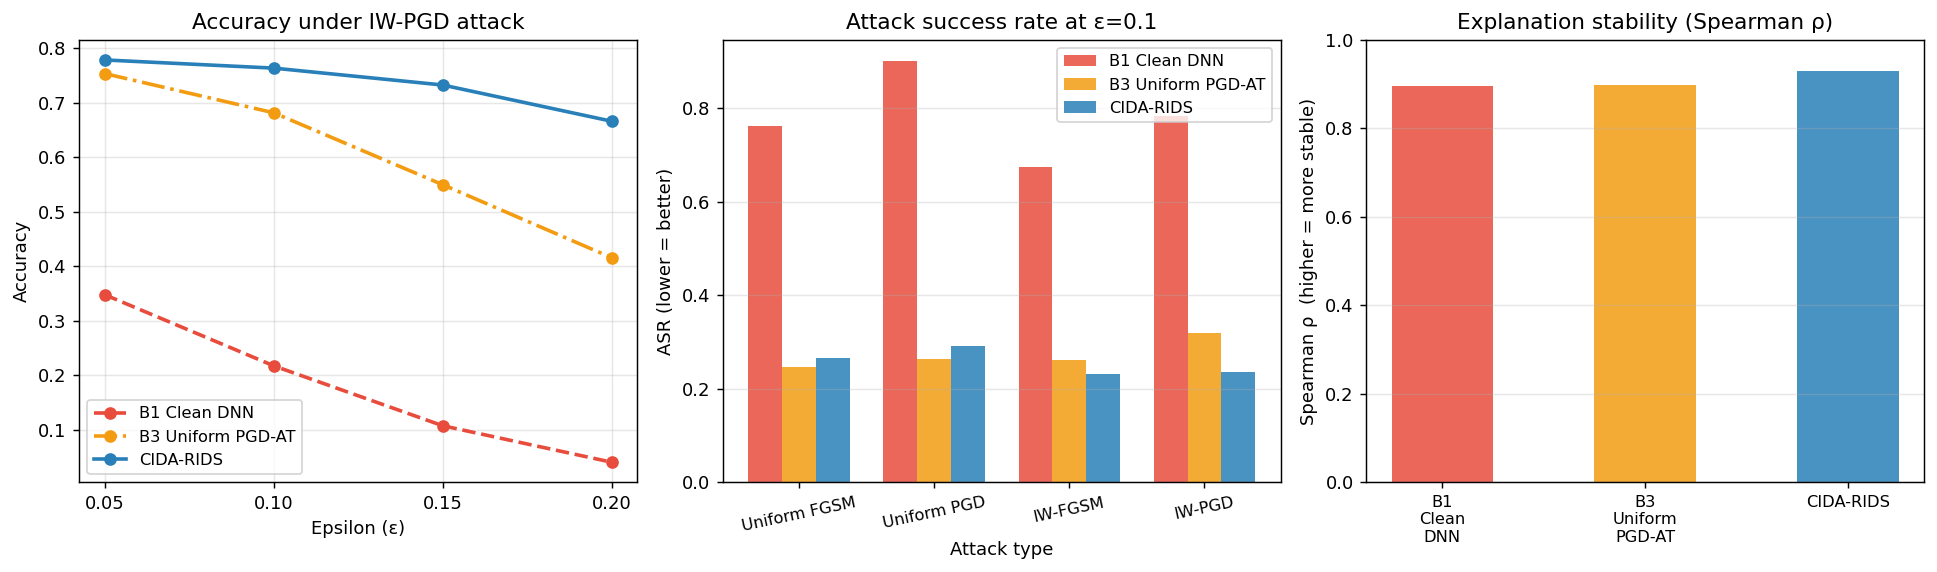

Saved: cida_rids_results.png


In [20]:
COLORS = {
    "B1 Clean DNN":      ("#e74c3c", "--"),
    "B3 Uniform PGD-AT": ("#f39c12", "-."),
    "CIDA-RIDS":         ("#2980b9", "-"),
}
ATTACKS  = ["Uniform FGSM", "Uniform PGD", "IW-FGSM", "IW-PGD"]
EPS_PLOT = 0.10

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Plot 1: Accuracy under IW-PGD vs epsilon ─────────────────────────────────
for mname, (col, ls) in COLORS.items():
    sub = results_df[(results_df.model == mname) &
                     (results_df.attack == "IW-PGD")].sort_values("epsilon")
    axes[0].plot(sub.epsilon, sub.acc_under_attack,
                 marker="o", color=col, ls=ls, lw=2, label=mname)
axes[0].set_title("Accuracy under IW-PGD attack", fontsize=12)
axes[0].set_xlabel("Epsilon (ε)")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(EPSILONS)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# ── Plot 2: ASR bar chart across attack types at fixed ε ─────────────────────
x   = np.arange(len(ATTACKS))
w   = 0.25
for i, (mname, (col, _)) in enumerate(COLORS.items()):
    asrs = [results_df[(results_df.model  == mname) &
                       (results_df.attack == atk)   &
                       (results_df.epsilon == EPS_PLOT)]["asr"].values[0]
            for atk in ATTACKS]
    axes[1].bar(x + i*w, asrs, w, label=mname, color=col, alpha=0.85)
axes[1].set_title(f"Attack success rate at ε={EPS_PLOT}", fontsize=12)
axes[1].set_xlabel("Attack type")
axes[1].set_ylabel("ASR (lower = better)")
axes[1].set_xticks(x + w)
axes[1].set_xticklabels(ATTACKS, rotation=12, fontsize=9)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3, axis="y")

# ── Plot 3: Explanation stability bar ────────────────────────────────────────
mnames = list(COLORS.keys())
rhos   = [rho_b1, rho_b3, rho_cida]
cols   = [COLORS[m][0] for m in mnames]
axes[2].bar(mnames, rhos, color=cols, alpha=0.85, width=0.5)
axes[2].set_title("Explanation stability (Spearman ρ)", fontsize=12)
axes[2].set_ylabel("Spearman ρ  (higher = more stable)")
axes[2].set_ylim(0, 1)
axes[2].set_xticklabels([m.replace(" ", "\n") for m in mnames], fontsize=9)
axes[2].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("cida_rids_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cida_rids_results.png")


## 17. CIDA-RIDS Training Curve

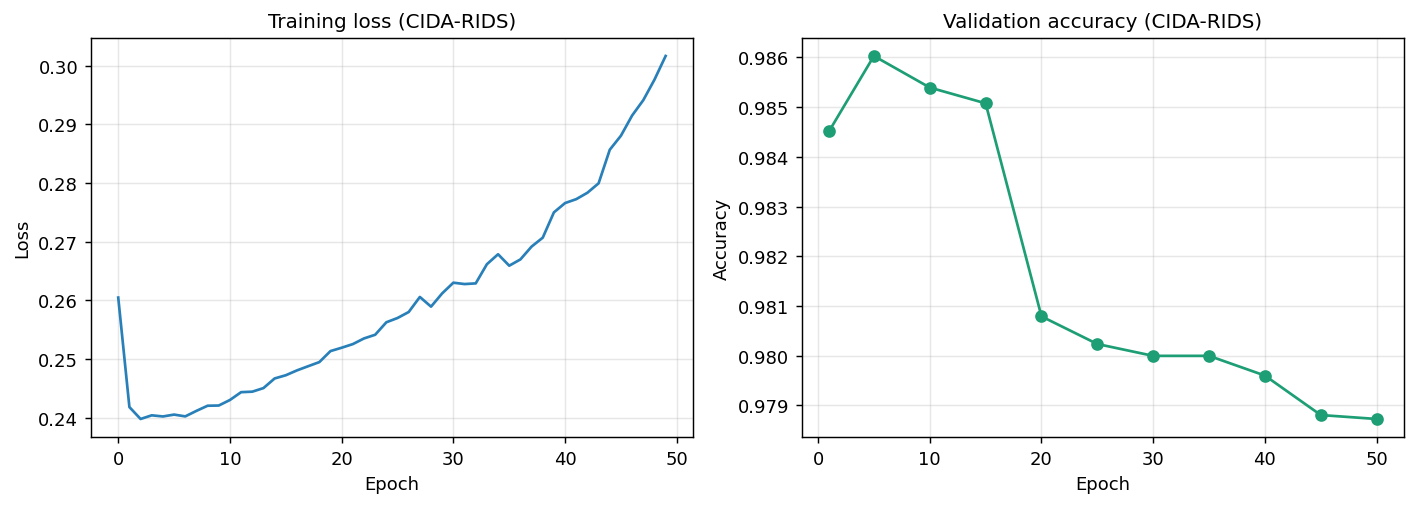

Saved: cida_rids_training_curve.png


In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(train_losses, color="#2980b9", lw=1.5)
ax1.set_title("Training loss (CIDA-RIDS)", fontsize=11)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.grid(alpha=0.3)

val_epochs = [1] + list(range(5, 51, 5))[:len(val_accs)-1]
if len(val_epochs) > len(val_accs):
    val_epochs = val_epochs[:len(val_accs)]
ax2.plot(val_epochs, val_accs, color="#1D9E75", marker="o", lw=1.5)
ax2.set_title("Validation accuracy (CIDA-RIDS)", fontsize=11)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("cida_rids_training_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cida_rids_training_curve.png")


## 18. Final Summary

In [22]:
print("=" * 60)
print("CIDA-RIDS PIPELINE COMPLETE")
print("=" * 60)

print("\n[D1] Codebase:")
print("  This notebook — full pipeline, reproducible on Colab")

print("\n[D2] Saved checkpoints:")
for f in sorted(os.listdir("checkpoints")):
    print(f"  checkpoints/{f}")

print("\n[D3] Results files:")
for f in ["cida_rids_robustness_results.csv", "cida_rids_stability.csv",
          "cida_rids_results.png", "cida_rids_training_curve.png"]:
    if os.path.exists(f):
        print(f"  {f}")

print("\n[Clean Accuracy]")
print(f"  B1 Clean DNN:      {clean_b1:.4f}")
print(f"  B3 Uniform PGD-AT: {clean_b3:.4f}")
print(f"  CIDA-RIDS:         {clean_cida:.4f}")

print("\n[Explanation Stability — Spearman ρ @ ε=0.10]")
print(f"  B1 Clean DNN:      {rho_b1:.4f}")
print(f"  B3 Uniform PGD-AT: {rho_b3:.4f}")
print(f"  CIDA-RIDS:         {rho_cida:.4f}")

print("\n[Robustness @ ε=0.10, IW-PGD]")
for mname, model, clean in models_to_eval:
    row = results_df[(results_df.model==mname)&(results_df.attack=="IW-PGD")&(results_df.epsilon==0.10)]
    if not row.empty:
        print(f"  {mname:<25} ASR={row['asr'].values[0]:.4f}  Gap={row['robustness_gap'].values[0]:+.4f}")


CIDA-RIDS PIPELINE COMPLETE

[D1] Codebase:
  This notebook — full pipeline, reproducible on Colab

[D2] Saved checkpoints:
  checkpoints/b1_clean_dnn.pt
  checkpoints/b3_uniform_pgd.pt
  checkpoints/cida_rids.pt
  checkpoints/denoiser.pt

[D3] Results files:
  cida_rids_robustness_results.csv
  cida_rids_stability.csv
  cida_rids_results.png
  cida_rids_training_curve.png

[Clean Accuracy]
  B1 Clean DNN:      0.7985
  B3 Uniform PGD-AT: 0.7531
  CIDA-RIDS:         0.7758

[Explanation Stability — Spearman ρ @ ε=0.10]
  B1 Clean DNN:      0.8960
  B3 Uniform PGD-AT: 0.8988
  CIDA-RIDS:         0.9288

[Robustness @ ε=0.10, IW-PGD]
  B1 Clean DNN              ASR=0.7830  Gap=+0.5815
  B3 Uniform PGD-AT         ASR=0.3185  Gap=+0.0716
  CIDA-RIDS                 ASR=0.2365  Gap=+0.0123


---
## 19. SENSITIVITY ANALYSIS

Tests how CIDA-RIDS robustness changes when key hyperparameters are varied.  
Three axes of sensitivity:
- **S1** — Label smoothing α (C3): `[0.0, 0.05, 0.1, 0.15, 0.2]`
- **S2** — Curriculum shape (N2): `linear`, `cosine`, `step`
- **S3** — Attack-mix ratio (N3): proportion of IW-PGD vs IW-FGSM vs Gaussian

Each variant trains for **30 epochs** (reduced from 50 for speed) and is evaluated  
under IW-PGD at ε=0.10 on `fast_loader` (2000 samples).  
All other hyperparameters are fixed at the CIDA-RIDS defaults.


### Sensitivity Trainer (shared helper)

In [23]:
import math

def sensitivity_trainer(label_smoothing=0.1, curriculum_shape="linear",
                        attack_mix=(0.50, 0.25, 0.25),
                        epochs=30, epsilon_max=0.20, epsilon_min=0.01):
    """
    Trains a fresh CIDA-RIDS variant with the specified hyperparameters.
    Returns (model, clean_acc, acc_under_attack, asr, robustness_gap).
    """
    model     = ClassifierMLP(input_dim, num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    p_pgd, p_fgsm, p_gauss = attack_mix
    assert abs(p_pgd + p_fgsm + p_gauss - 1.0) < 1e-6, "mix must sum to 1"

    def get_eps(epoch):
        t = epoch / max(1, epochs - 1)
        if curriculum_shape == "linear":
            return epsilon_min + t * (epsilon_max - epsilon_min)
        elif curriculum_shape == "cosine":
            return epsilon_min + (1 - math.cos(math.pi * t)) / 2 * (epsilon_max - epsilon_min)
        elif curriculum_shape == "step":
            # three equal steps: low / mid / high
            if t < 1/3:   return epsilon_min
            elif t < 2/3: return epsilon_min + 0.5 * (epsilon_max - epsilon_min)
            else:         return epsilon_max
        else:
            raise ValueError(f"Unknown curriculum_shape: {curriculum_shape}")

    for epoch in range(epochs):
        model.train()
        eps = get_eps(epoch)
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            r = np.random.rand()
            if r < p_pgd:
                adv = iw_pgd_attack(model, bx, by, epsilon_total=eps,
                                    importance_vector=imp_vec_sel,
                                    mutability_mask=mutability_mask,
                                    steps=10, alpha=eps/4)
            elif r < p_pgd + p_fgsm:
                adv = iw_fgsm_attack(model, bx, by, epsilon_total=eps,
                                     importance_vector=imp_vec_sel,
                                     mutability_mask=mutability_mask)
            else:
                adv = bx + torch.randn_like(bx) * 0.05
            optimizer.zero_grad()
            criterion(model(adv), by).backward()
            optimizer.step()

    # Evaluate
    c_acc = clean_acc(model, test_loader)
    a_acc, asr = evaluate_attack(
        model, fast_loader, iw_pgd_attack,
        epsilon_total=0.10, importance_vector=imp_vec_sel,
        mutability_mask=mutability_mask, steps=10, alpha=0.025
    )
    return model, c_acc, a_acc, asr, c_acc - a_acc

print("sensitivity_trainer() defined.")


sensitivity_trainer() defined.


### S1 — Label Smoothing α

In [24]:
alpha_values = [0.0, 0.05, 0.10, 0.15, 0.20]
s1_rows = []

print("S1: Label Smoothing α sensitivity")
print(f"{'α':<8} {'Clean Acc':>10} {'Atk Acc':>10} {'ASR':>8} {'Gap':>8}")
print("-" * 46)

for alpha in alpha_values:
    _, c_acc, a_acc, asr, gap = sensitivity_trainer(label_smoothing=alpha)
    s1_rows.append(dict(alpha=alpha, clean_acc=c_acc,
                        acc_under_attack=a_acc, asr=asr, gap=gap))
    print(f"{alpha:<8.2f} {c_acc:>10.4f} {a_acc:>10.4f} {asr:>8.4f} {gap:>8.4f}")

s1_df = pd.DataFrame(s1_rows)
s1_df.to_csv("sensitivity_alpha.csv", index=False)
print("\nSaved: sensitivity_alpha.csv")


S1: Label Smoothing α sensitivity
α         Clean Acc    Atk Acc      ASR      Gap
----------------------------------------------
0.00         0.7711     0.7530   0.2470   0.0181
0.05         0.7748     0.7690   0.2310   0.0058
0.10         0.7718     0.7575   0.2425   0.0143
0.15         0.7703     0.7670   0.2330   0.0033
0.20         0.7715     0.7665   0.2335   0.0050

Saved: sensitivity_alpha.csv


### S2 — Curriculum Shape

In [25]:
shapes = ["linear", "cosine", "step"]
s2_rows = []

print("S2: Curriculum Shape sensitivity")
print(f"{'Shape':<10} {'Clean Acc':>10} {'Atk Acc':>10} {'ASR':>8} {'Gap':>8}")
print("-" * 48)

for shape in shapes:
    _, c_acc, a_acc, asr, gap = sensitivity_trainer(curriculum_shape=shape)
    s2_rows.append(dict(shape=shape, clean_acc=c_acc,
                        acc_under_attack=a_acc, asr=asr, gap=gap))
    print(f"{shape:<10} {c_acc:>10.4f} {a_acc:>10.4f} {asr:>8.4f} {gap:>8.4f}")

s2_df = pd.DataFrame(s2_rows)
s2_df.to_csv("sensitivity_curriculum.csv", index=False)
print("\nSaved: sensitivity_curriculum.csv")


S2: Curriculum Shape sensitivity
Shape       Clean Acc    Atk Acc      ASR      Gap
------------------------------------------------
linear         0.7753     0.7710   0.2290   0.0043
cosine         0.7753     0.7660   0.2340   0.0093
step           0.7715     0.7665   0.2335   0.0050

Saved: sensitivity_curriculum.csv


### S3 — Attack-Mix Ratio

In [26]:
# Vary IW-PGD proportion; split remainder equally between IW-FGSM and Gaussian
mix_configs = [
    ("PGD-heavy",     (0.70, 0.15, 0.15)),
    ("Balanced",      (0.50, 0.25, 0.25)),   # CIDA-RIDS default
    ("FGSM-heavy",    (0.30, 0.50, 0.20)),
    ("Gauss-heavy",   (0.30, 0.20, 0.50)),
    ("PGD-only",      (1.00, 0.00, 0.00)),
]

s3_rows = []
print("S3: Attack-Mix Ratio sensitivity (evaluated under IW-PGD ε=0.10)")
print(f"{'Mix':<16} {'p_PGD':>6} {'p_FGSM':>7} {'p_Gauss':>8} {'ASR':>8} {'Gap':>8}")
print("-" * 55)

for name, mix in mix_configs:
    _, c_acc, a_acc, asr, gap = sensitivity_trainer(attack_mix=mix)
    s3_rows.append(dict(mix=name, p_pgd=mix[0], p_fgsm=mix[1], p_gauss=mix[2],
                        clean_acc=c_acc, acc_under_attack=a_acc, asr=asr, gap=gap))
    print(f"{name:<16} {mix[0]:>6.2f} {mix[1]:>7.2f} {mix[2]:>8.2f} {asr:>8.4f} {gap:>8.4f}")

s3_df = pd.DataFrame(s3_rows)
s3_df.to_csv("sensitivity_attackmix.csv", index=False)
print("\nSaved: sensitivity_attackmix.csv")


S3: Attack-Mix Ratio sensitivity (evaluated under IW-PGD ε=0.10)
Mix               p_PGD  p_FGSM  p_Gauss      ASR      Gap
-------------------------------------------------------
PGD-heavy          0.70    0.15     0.15   0.2385   0.0091
Balanced           0.50    0.25     0.25   0.2295   0.0010
FGSM-heavy         0.30    0.50     0.20   0.2345   0.0061
Gauss-heavy        0.30    0.20     0.50   0.2450   0.0225
PGD-only           1.00    0.00     0.00   0.2355   0.0061

Saved: sensitivity_attackmix.csv


### Sensitivity Analysis — Plots

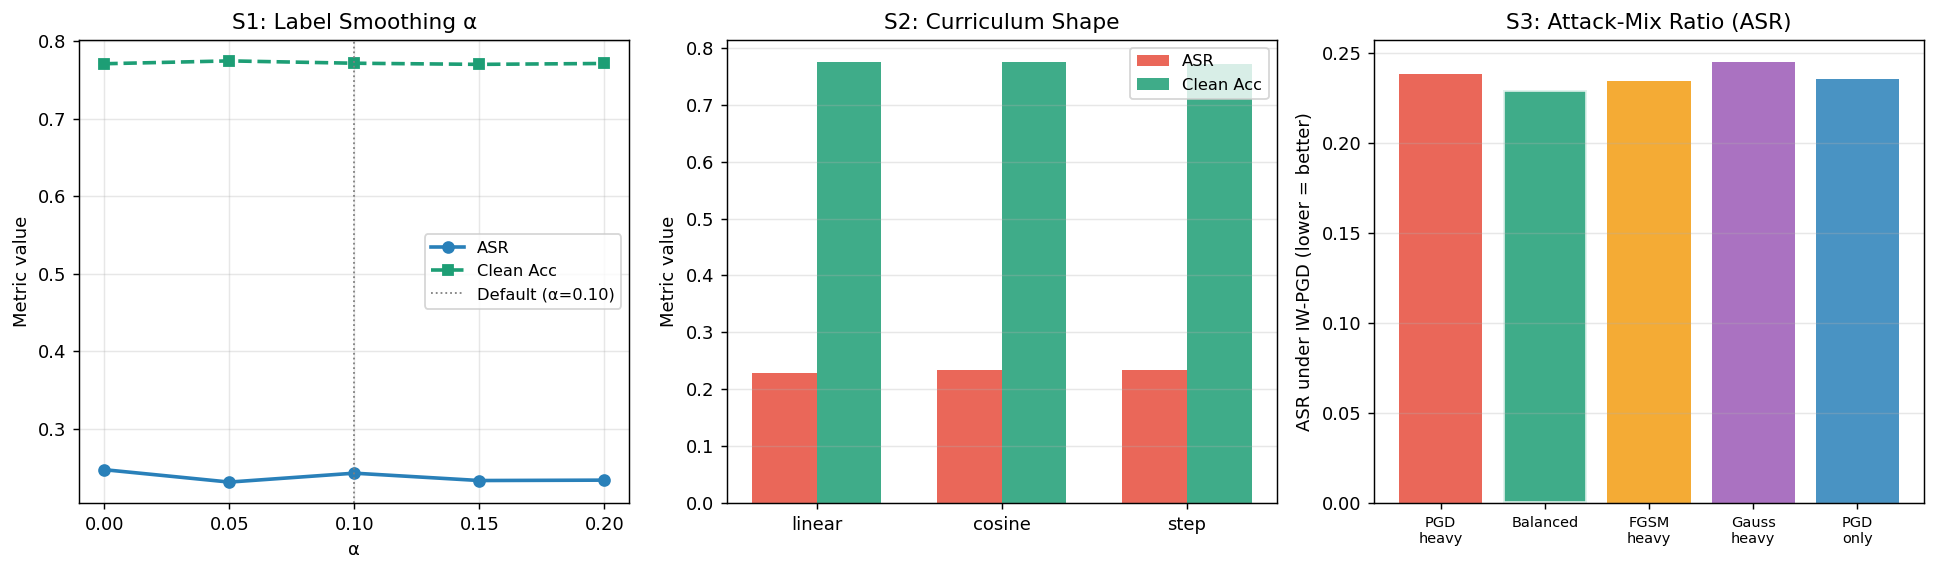

Saved: sensitivity_results.png


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── S1: α vs ASR ─────────────────────────────────────────────────────────────
axes[0].plot(s1_df["alpha"], s1_df["asr"],
             marker="o", color="#2980b9", lw=2, label="ASR")
axes[0].plot(s1_df["alpha"], s1_df["clean_acc"],
             marker="s", color="#1D9E75", lw=2, ls="--", label="Clean Acc")
axes[0].axvline(0.10, color="gray", lw=1, ls=":", label="Default (α=0.10)")
axes[0].set_title("S1: Label Smoothing α", fontsize=12)
axes[0].set_xlabel("α"); axes[0].set_ylabel("Metric value")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
axes[0].set_xticks(s1_df["alpha"])

# ── S2: Curriculum shape bar ──────────────────────────────────────────────────
x = np.arange(len(s2_df))
w = 0.35
axes[1].bar(x - w/2, s2_df["asr"],        w, color="#e74c3c", alpha=0.85, label="ASR")
axes[1].bar(x + w/2, s2_df["clean_acc"],  w, color="#1D9E75", alpha=0.85, label="Clean Acc")
axes[1].set_title("S2: Curriculum Shape", fontsize=12)
axes[1].set_xticks(x); axes[1].set_xticklabels(s2_df["shape"])
axes[1].set_ylabel("Metric value"); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3, axis="y")

# ── S3: Attack mix vs ASR ─────────────────────────────────────────────────────
colors_s3 = ["#e74c3c","#1D9E75","#f39c12","#9b59b6","#2980b9"]
bars = axes[2].bar(range(len(s3_df)), s3_df["asr"],
                   color=colors_s3[:len(s3_df)], alpha=0.85)
axes[2].set_title("S3: Attack-Mix Ratio (ASR)", fontsize=12)
axes[2].set_xticks(range(len(s3_df)))
axes[2].set_xticklabels([r.replace("-", "\n") for r in s3_df["mix"]], fontsize=8)
axes[2].set_ylabel("ASR under IW-PGD (lower = better)")
axes[2].grid(alpha=0.3, axis="y")
# mark default
default_idx = list(s3_df["mix"]).index("Balanced")
axes[2].patches[default_idx].set_edgecolor("white")
axes[2].patches[default_idx].set_linewidth(2)
axes[2].annotate("default", xy=(default_idx, s3_df["asr"].iloc[default_idx]),
                 xytext=(default_idx + 0.3, s3_df["asr"].iloc[default_idx] + 0.01),
                 fontsize=8, color="white")

plt.tight_layout()
plt.savefig("sensitivity_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sensitivity_results.png")


### Sensitivity Summary Table

In [28]:
print("=" * 60)
print("SENSITIVITY ANALYSIS SUMMARY")
print("=" * 60)

print("\n[S1] Label Smoothing α  (IW-PGD ε=0.10, 30 epochs)")
print(s1_df.to_string(index=False))

print("\n[S2] Curriculum Shape  (IW-PGD ε=0.10, 30 epochs)")
print(s2_df.to_string(index=False))

print("\n[S3] Attack-Mix Ratio  (IW-PGD ε=0.10, 30 epochs)")
print(s3_df[["mix","p_pgd","p_fgsm","p_gauss","asr","gap"]].to_string(index=False))

print("\nOutput files:")
for f in ["sensitivity_alpha.csv", "sensitivity_curriculum.csv",
          "sensitivity_attackmix.csv", "sensitivity_results.png"]:
    import os
    if os.path.exists(f):
        print(f"  {f}")


SENSITIVITY ANALYSIS SUMMARY

[S1] Label Smoothing α  (IW-PGD ε=0.10, 30 epochs)
 alpha  clean_acc  acc_under_attack    asr      gap
  0.00   0.771114            0.7530 0.2470 0.018114
  0.05   0.774796            0.7690 0.2310 0.005796
  0.10   0.771780            0.7575 0.2425 0.014280
  0.15   0.770316            0.7670 0.2330 0.003316
  0.20   0.771469            0.7665 0.2335 0.004969

[S2] Curriculum Shape  (IW-PGD ε=0.10, 30 epochs)
 shape  clean_acc  acc_under_attack    asr      gap
linear   0.775328            0.7710 0.2290 0.004328
cosine   0.775284            0.7660 0.2340 0.009284
  step   0.771513            0.7665 0.2335 0.005013

[S3] Attack-Mix Ratio  (IW-PGD ε=0.10, 30 epochs)
        mix  p_pgd  p_fgsm  p_gauss    asr      gap
  PGD-heavy    0.7    0.15     0.15 0.2385 0.009126
   Balanced    0.5    0.25     0.25 0.2295 0.000969
 FGSM-heavy    0.3    0.50     0.20 0.2345 0.006102
Gauss-heavy    0.3    0.20     0.50 0.2450 0.022457
   PGD-only    1.0    0.00     0.00 0